<a href="https://colab.research.google.com/github/vv2281/MAT-422/blob/main/HW_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1.3.1 Decomposition


QR decomposition factors a matrix A into two matrices

A = QR where Q has orthonormal columns. Also, where R is an upper triangular matrix.

QR decomposition is useful in numerial algebra because it is used to solve systems of equations and problems with least-squares.

Below I will create a matrix and use NumPy to find its QR decomposition.

In [3]:
import numpy as np

A = np.array([
    [1,2],
    [3,4],
    [5,6]
])

print("Matrix A:")
print(A)

#compute the QR decomposition

Q, R = np.linalg.qr(A)
print("Matrix Q:")
print(Q)

print("\nMatrix R:")
print(R)

Matrix A:
[[1 2]
 [3 4]
 [5 6]]
Matrix Q:
[[-0.16903085  0.89708523]
 [-0.50709255  0.27602622]
 [-0.84515425 -0.34503278]]

Matrix R:
[[-5.91607978 -7.43735744]
 [ 0.          0.82807867]]


## Verifying the decomposition

We can multiply Q and R to check if the QR decomposition is correct. The product should reproduce the original matrix A.

To check if the columns of Q are orthonormal, we must calculate Q^TQ. This should equal the identity matrix if so.

In [7]:
#reconstruct A from Q and R

A_reconstructed = Q @ R

print("Q multiplied by R:")
print(A_reconstructed)

print("\nOriginal A:")
print(A)

print("\nOriginal A:")
print(A)

print("\nDoes QR equal A?")
print(np.allclose(A_reconstructed, A))

##checking that Q has orthonormal columns
QTQ = Q.T @ Q
print("Q^T Q:")
print(QTQ)

print("\nIs Q orthogonal?")

print(np.allclose(QTQ, np.eye(Q.shape[1])))

Q multiplied by R:
[[1. 2.]
 [3. 4.]
 [5. 6.]]

Original A:
[[1 2]
 [3 4]
 [5 6]]

Original A:
[[1 2]
 [3 4]
 [5 6]]

Does QR equal A?
True
Q^T Q:
[[1.00000000e+00 6.18439648e-17]
 [6.18439648e-17 1.00000000e+00]]

Is Q orthogonal?
True


## 1.3.2 Least Squares Problems

A least-squares problem occurs when we want to solve Ax ≈ b but there is no exact solution that satisfies every equation. Instead of needing an exact solution, the least-squares method finds the value of x that minimizes the squared error. This is useful for overdetermined systems.





In [8]:
#create an overdetermined system Ax approx. equals b

A = np.array([
    [1,1],
    [1,2],
    [1,3],
    [1,4],
])

b = np.array([2,3,5,4])

print("Matrix A:")
print(A)

print("\nVector b:")
print(b)

Matrix A:
[[1 1]
 [1 2]
 [1 3]
 [1 4]]

Vector b:
[2 3 5 4]


##Solving the least-squares problems

NumPy's np.linalg.lstsq() function calculates a least-squares solution. The result contains the values of x that give the best approximation to the system.

In [9]:
#find the least-squares solution

x, residuals, rank, singular_values = np.linalg.lstsq(
    A, b, rcond=None
)

print("Least-squares solution")
print(x)

Least-squares solution
[1.5 0.8]


##Calculating the predicted values and residuals

Once we have the least-squares solution, we can calculate the predicted values using

b(^) = Ax

the residual vector is r = b - Ax. The residual tells us how far each predicted value is from the actual value.

In [12]:
#calculate predicted values
b_predicted = A @ x

#calculate residuals
residual = b - b_predicted

print("Predicted values:")
print(b_predicted)

print("\nResiduals:")
print(residual)

#calculate the sum of squared errors
squared_error = np.sum(residual**2)

print("sum of squared errorsL")
print(squared_error)

Predicted values:
[2.3 3.1 3.9 4.7]

Residuals:
[-0.3 -0.1  1.1 -0.7]
sum of squared errorsL
1.8000000000000003


##Solving least squares using QR decomposition

QR decomposition provides another way to solve the least-squares problem. If A = QR then Ax ≈ b becomes QRx ≈ b. Multiplying by Q^T gives the smaller system Rx = Q^Tb. This system can be solved using Python:

In [14]:
#compute the QR decomposition of A
Q, R  = np.linalg.qr(A)

#solve Rx = Q^Tb
x_qr = np.linalg.solve(R, Q.T @ b)
print("Least-squares solution using QR decomposition:")
print(x_qr)

#compare the two least-squares solutions
print("Solution using np.linalg.lstsq():")
print(x)

print("\nSolution using QR decomposition:")
print(x_qr)

print("\nAre the solutions approximately equal?")
print(np.allclose(x,x_qr))


Least-squares solution using QR decomposition:
[1.5 0.8]
Solution using np.linalg.lstsq():
[1.5 0.8]

Solution using QR decomposition:
[1.5 0.8]

Are the solutions approximately equal?
True


##Least-squares results

The two methods produce approximately the same solution. This demonstrates that QR decomposition can be used as a numerial method for solving least-squares problems. Additionally, the residuals are not all zero because this is an overdetermined system; instead, the solution minimizes the total squared error.

##1.3.3 Linear Regression

Linear regression is used to model the relationship between an independent variable x and a dependent variable y.

A linear regression model has the form: y = b(0) + b(1)x where b0 is the intercept, b1 is the slope, x is the independent variable, and y is the dependent variable.

The least-squares method can be used to find the values of b0 and b1 that produce the best-fitting line.

In [15]:
##example data
hours = np.array([1,2,3,4,5,6])
scores = np.array([55,60,65,70,74,80])

print("hours studied:")
print(hours)

print("\ntest scores:")
print(scores)

hours studied:
[1 2 3 4 5 6]

test scores:
[55 60 65 70 74 80]


##Creating the design matrix

To write linear regression as a least-squares problem, we should create a design matrix.a The first column contains ones for the intercept, and the second column contains the x-values.

The system is (basically): A [b0, b1]^T ≈ y . This allows us to use the same least-squares method from the previous section

In [16]:
#create the design matrix

A = np.column_stack((np.ones(len(hours)),hours))

print("Design matrix A:")
print(A)

Design matrix A:
[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]
 [1. 6.]]


##Finding the Regression Coefficients

We can use np.lingalg.lstsq() to find the intercept and slope. The first coefficient is b0 (the intercept). The second coefficient is b1 (the slope).

In [19]:
#find the least-squares regression coefficients

coefficients, residuals, rank, singular_values = np.linalg.lstsq(
    A, scores, rcond=None
)

b0, b1 = coefficients

print("Intercept:", b0)
print("Slope:", b1)

#display the regression equation

print(f"Regression equation y = {b0:.2f} + {b1:.2f}x")

Intercept: 50.1333333333334
Slope: 4.914285714285709
Regression equation y = 50.13 + 4.91x


##Interpreting the Regression Equation
The intercept represents the predicted test score when the number of hours studied is zero. The slope represents the predicted change in test score for each additional hour studied. Because in this example the slope is positive, the model indicates that test scores tend to increase as study hours increase..

##Plotting the Data and Regression Line

A graph makes it easier to see how well the line represents the data. The points represent the observed test scores, while the line represents the least-squares regression model.

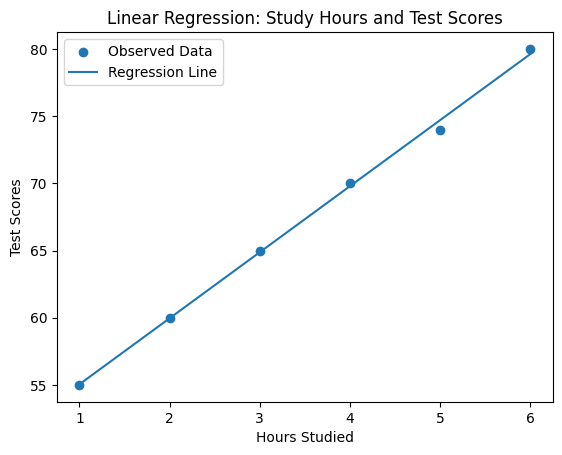

In [20]:
import matplotlib.pyplot as plt

#Calculate predicted scores from the regression equation

predicted_scores = b0 + b1 * hours

#plot the observed data

plt.scatter(hours, scores, label="Observed Data")

#plot the regression line
plt.plot(hours, predicted_scores, label="Regression Line")

plt.xlabel("Hours Studied")
plt.ylabel("Test Scores")
plt.title("Linear Regression: Study Hours and Test Scores")
plt.legend()
plt.show()

##Making a Prediction

Once the regression equation has been calculated, it can be used to make predictions. For example, we can estimate the test score for a student who studies for 7 hours

In [21]:
#predict the score for 7 hours of studying

hours_to_predict = 7
predicted_score = b0 + b1 * hours_to_predict

print(
    f"Predicted score for {hours_to_predict} hours of studying: "
    f"{predicted_score:.2f}"
)


Predicted score for 7 hours of studying: 84.53


#Connection Between the Three Concepts

The three concepts in section 1.3 are connected.

###QR DECOMPOSITION

QR decomposition factors a matrix into: A = QR.

###Least-Squares Problems

QR decomposition can be used to solve: Ax ≈ b by transforming the problem into a system involving R.

###Linear Regression

Linear regression can be written as a least-squares problem. The regression coefficients are found by minimizing the squared differences between the observed and predicted values.

Therefore, the ideas are connected as QR decomposition -> Least-Squares Problems -> Linear Regression.

The examples in this file show how a concept from linear algebra can be used as the foundation for solving practical data fitting problems.